# TRAINING MODELS

## BILSTM Model for Headlines

In [77]:
# ==========================================================
# Import all required libraries
# ==========================================================

import os
import pickle
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model

from tensorflow.keras.layers import (

    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    SpatialDropout1D,
    BatchNormalization

)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (

    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint

)

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,

    confusion_matrix,
    classification_report,

    roc_curve,
    auc,

    precision_recall_curve

)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [78]:
# Define the base path where the headline datasets were saved
drive_path = r'E:/FYP PROJECT'

# ==========================================================
# LOAD PREPROCESSED DATA
# ==========================================================

X_train = np.load(os.path.join(drive_path, "X_train.npy"))
X_val = np.load(os.path.join(drive_path, "X_val.npy"))
X_test = np.load(os.path.join(drive_path, "X_test.npy"))

y_train = np.load(os.path.join(drive_path, "y_train.npy"))
y_val = np.load(os.path.join(drive_path, "y_val.npy"))
y_test = np.load(os.path.join(drive_path, "y_test.npy"))

print("Training:", X_train.shape)

print("Validation:", X_val.shape)

print("Testing:", X_test.shape)

Training: (22397, 13)
Validation: (4799, 13)
Testing: (4800, 13)


In [79]:
# Define the base path where the tokenizer was saved
tokenizer_load_path = os.path.join(drive_path, "headline_tokenizer.pkl")

# ==========================================================
# LOAD TOKENIZER
# ==========================================================

with open(

    tokenizer_load_path,

    "rb"

) as file:

    tokenizer = pickle.load(file)

print("Tokenizer Loaded")

vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary Size:", vocab_size)

Tokenizer Loaded
Vocabulary Size: 20278


In [80]:
# ==========================================================
# VERIFY DATA
# ==========================================================

print("="*60)

print("TRAIN")

print(X_train.shape)

print(y_train.shape)

print("="*60)

print("VALIDATION")

print(X_val.shape)

print(y_val.shape)

print("="*60)

print("TEST")

print(X_test.shape)

print(y_test.shape)

print("="*60)

print("Maximum Token ID:", np.max(X_train))

print("Vocabulary Size:", vocab_size)

assert np.max(X_train) < vocab_size


TRAIN
(22397, 13)
(22397,)
VALIDATION
(4799, 13)
(4799,)
TEST
(4800, 13)
(4800,)
Maximum Token ID: 20277
Vocabulary Size: 20278


In [106]:
# ==========================================================
# HYPERPARAMETERS
# ==========================================================

MAX_LENGTH = X_train.shape[1]

VOCAB_SIZE = vocab_size

EMBEDDING_DIM = 64

LSTM_UNITS = 64

DENSE_UNITS = 32

DROPOUT_RATE = 0.4

LEARNING_RATE = 1e-3

L2_WEIGHT = 1e-4

BATCH_SIZE = 64

EPOCHS = 30

In [107]:
# ==========================================================
# CREATE DIRECTORIES
# ==========================================================

drive_path = r'E:/FYP PROJECT'
os.makedirs(drive_path, exist_ok=True) # Ensure the base directory exists

os.makedirs(os.path.join(drive_path, "models"), exist_ok=True)
os.makedirs(os.path.join(drive_path, "history"), exist_ok=True)

In [108]:
# ==========================================================
# BUILD BILSTM MODEL
# ==========================================================

input_text = Input(
    shape=(MAX_LENGTH,),
    name="headline_input"
)

# Embedding Layer
embedding = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    trainable=True,
    name="embedding"
)(input_text)

# Spatial Dropout
x = SpatialDropout1D(

    0.30,

    name="spatial_dropout"

)(embedding)

# BiLSTM Layer
x = Bidirectional(
    LSTM(
        LSTM_UNITS,
        return_sequences=False,
        dropout=0.2,
        recurrent_dropout=0.2
    ),
    name="bilstm"
)(x)

# Batch Normalization
x = BatchNormalization(

    name="batch_norm"

)(x)


# Dropout
x = Dropout(
    DROPOUT_RATE,
    name="dropout_1"
)(x)

# Dense Layer
x = Dense(
    DENSE_UNITS,
    activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(L2_WEIGHT),
    name="dense_1"
)(x)

# Dropout
x = Dropout(
    0.30,
    name="dropout_2"
)(x)

# Output
output = Dense(
    1,
    activation="sigmoid",
    name="output"
)(x)

headline_model = Model(
    inputs=input_text,
    outputs=output,
    name="Headline_BiLSTM"
)

headline_model.summary()

Model: "Headline_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ headline_input (InputLayer)          │ (None, 13)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 13, 64)              │       1,297,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout (SpatialDropout1D)   │ (None, 13, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bilstm (Bidirectional)               │ (None, 128)                 │          66,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_norm (BatchNormalization)      │ (None, 128)                 │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,368,513 (5.22 MB)

 Trainable params: 1,368,257 (5.22 MB)

 Non-trainable params: 256 (1.00 KB)

In [109]:
# ==========================================================
# COMPILE MODEL
# ==========================================================

optimizer = Adam(
    learning_rate=LEARNING_RATE
)

headline_model.compile(

    optimizer=optimizer,

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]

)

In [111]:
# ==========================================================
# CALLBACKS
# ==========================================================

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    min_delta = 0.0005,

    restore_best_weights=True,

    verbose=1

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=5,

    min_lr=1e-6,

    verbose=1

)

checkpoint = ModelCheckpoint(

    os.path.join(drive_path, "models", "headline_bilstm.keras"),

    monitor="val_loss",

    save_best_only=True,

    mode = "min",

    verbose=1

)

In [112]:
# ==========================================================
# TRAIN MODEL
# ==========================================================
import time

start_train = time.time()

history = headline_model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    batch_size=BATCH_SIZE,

    epochs=EPOCHS,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],
    shuffle = True,
    verbose=1

)

end_train = time.time()
training_time = end_train - start_train

print(f"Training time (secs): {training_time:.4f}")  
print(f"Training time (mins): {training_time/60:.4f}")

Epoch 1/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8434 - auc: 0.9132 - loss: 0.3279 - precision: 0.8650 - recall: 0.8073
Epoch 1: val_loss improved from None to 0.20223, saving model to E:/FYP PROJECT\models\headline_bilstm.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.9200 - auc: 0.9783 - loss: 0.1931 - precision: 0.9336 - recall: 0.9043 - val_accuracy: 0.9706 - val_auc: 0.9964 - val_loss: 0.2022 - val_precision: 0.9616 - val_recall: 0.9804 - learning_rate: 0.0010
Epoch 2/30
349/350 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9820 - auc: 0.9975 - loss: 0.0584 - precision: 0.9814 - recall: 0.9829
Epoch 2: val_loss improved from 0.20223 to 0.07764, saving model to E:/FYP PROJECT\models\headline_bilstm.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.9800 - auc: 0.9971 - loss: 0.0635 - precision: 0.9797 - recall: 0.9804 - val_accuracy: 0.9735 - val_auc: 0.9964 - val_loss: 0.0776 - val_precision: 0.9814 - val_recall: 0.9654 - learning_ra

In [113]:
# ==========================================================
# SAVE HISTORY
# ==========================================================

with open(
    os.path.join(path, "history", "headline_history.pkl"),
    "wb"
) as file:

    pickle.dump(
        history.history,
        file
    )

print("Training history saved.")

Training history saved.


In [114]:
# ==========================================================
# LOAD BEST MODEL
# ==========================================================

headline_model = tf.keras.models.load_model(
    r"E:/FYP PROJECT/models/headline_bilstm.keras"
)

In [116]:
# ==========================================================
# TEST PREDICTIONS
# ==========================================================
import time

start_inf = time.time()

y_prob = headline_model.predict(X_test)

y_pred = (y_prob >= 0.5).astype(int).flatten()

end_if = time.time()
inf_time = end_if - start_inf

print(f"Inferenece time (secs): {inf_time:.4f}")  
print(f"Inference time (mins): {inf_time/60:.4f}")

150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Inferenece time (secs): 1.2735
Inference time (mins): 0.0212


In [118]:
# ==========================================================
# CLASSIFICATION METRICS
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1-score : {f1:.4f}")

print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.9708
Precision: 0.9776
Recall   : 0.9637
F1-score : 0.9706
ROC-AUC  : 0.9960


In [119]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      2400
           1       0.98      0.96      0.97      2400

    accuracy                           0.97      4800
   macro avg       0.97      0.97      0.97      4800
weighted avg       0.97      0.97      0.97      4800



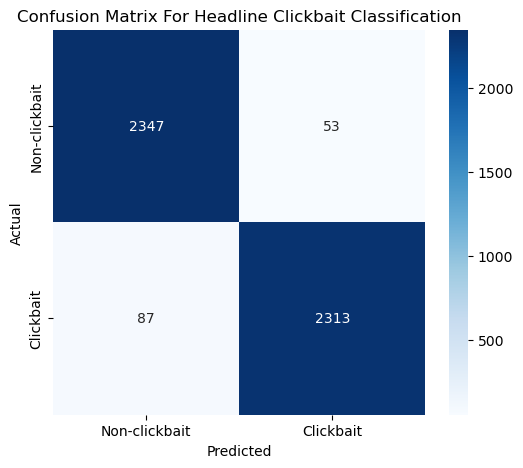

In [120]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=["Non-clickbait","Clickbait"],

    yticklabels=["Non-clickbait","Clickbait"]

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix For Headline Clickbait Classification")

plt.show()

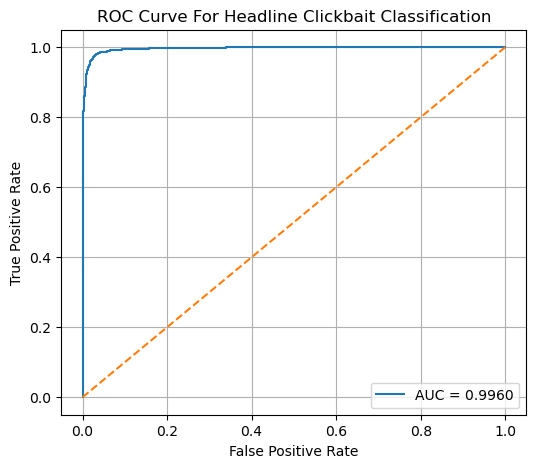

In [121]:
fpr, tpr, thresholds = roc_curve(

    y_test,

    y_prob

)

roc_auc = auc(

    fpr,

    tpr

)

plt.figure(figsize=(6,5))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {roc_auc:.4f}"

)

plt.plot(

    [0,1],

    [0,1],

    linestyle="--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve For Headline Clickbait Classification")

plt.legend()

plt.grid()


plt.show()

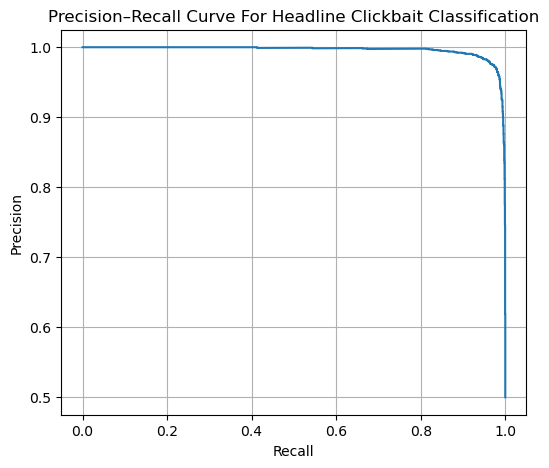

In [122]:
precision_curve, recall_curve, _ = precision_recall_curve(

    y_test,

    y_prob

)

plt.figure(figsize=(6,5))

plt.plot(

    recall_curve,

    precision_curve

)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision–Recall Curve For Headline Clickbait Classification")

plt.grid()


plt.show()

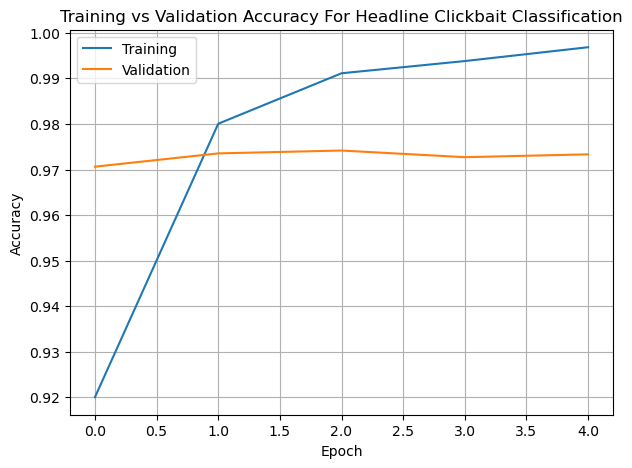

In [125]:
plt.figure(figsize=(7,5))

plt.plot(

    history.history["accuracy"],

    label="Training"

)

plt.plot(

    history.history["val_accuracy"],

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy For Headline Clickbait Classification")

plt.legend()

plt.grid()

plt.show()

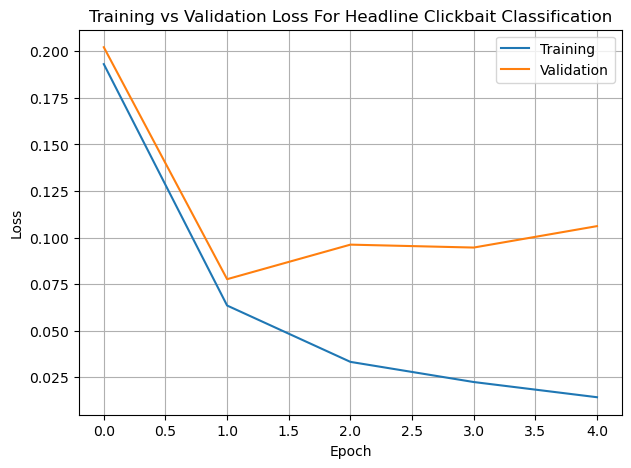

In [126]:
plt.figure(figsize=(7,5))

plt.plot(

    history.history["loss"],

    label="Training"

)

plt.plot(

    history.history["val_loss"],

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss For Headline Clickbait Classification")

plt.legend()

plt.grid()
plt.show()

In [127]:
results = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1-score",

        "ROC-AUC"

    ],

    "Value":[

        accuracy,

        precision,

        recall,

        f1,

        roc_auc

    ]

})

display(results)

,Metric,Value
0,Accuracy,0.970833
1,Precision,0.977599
2,Recall,0.963750
3,F1-score,0.970625
4,ROC-AUC,0.995973


## Hybrid Multimodal Model for YouTube Videos

In [4]:
# ========================
# Loading all the datasets
# ========================

import os
import numpy as np

# Define the base path for saving in Google Drive (from previous cells)
drive_path = r'E:/FYP PROJECT'

# Define the specific folder for YouTube datasets
youtube_datasets_path = os.path.join(drive_path, 'youtube_datasets')

print(f"Loading YouTube datasets from '{youtube_datasets_path} ...")

# Helper function to load .npy files
def load_npy_file(base_path, filename):
    full_path = os.path.join(base_path, filename)
    # Explicitly allow pickling for object arrays. Be cautious with untrusted sources.
    return np.load(full_path, allow_pickle=True)


# Load text datasets
X_text_train = load_npy_file(youtube_datasets_path, 'X_text_train.npy')
X_text_val = load_npy_file(youtube_datasets_path, 'X_text_val.npy')
X_text_test = load_npy_file(youtube_datasets_path, 'X_text_test.npy')


# Load image validation and test datasets
X_img_train = load_npy_file(youtube_datasets_path, 'X_img_train.npy')
X_img_val = load_npy_file(youtube_datasets_path, 'X_img_val.npy')
X_img_test = load_npy_file(youtube_datasets_path, 'X_img_test.npy')

# Load metadata datasets
X_meta_train = load_npy_file(youtube_datasets_path, 'X_meta_train.npy')
X_meta_val = load_npy_file(youtube_datasets_path, 'X_meta_val.npy')
X_meta_test = load_npy_file(youtube_datasets_path, 'X_meta_test.npy')

# Load label datasets
y_train = load_npy_file(youtube_datasets_path, 'y_train.npy')
y_val = load_npy_file(youtube_datasets_path, 'y_val.npy')
y_test = load_npy_file(youtube_datasets_path, 'y_test.npy')

print("All YouTube datasets loaded successfully.")

print("\n--- Loaded Data Shapes ---")
print("TEXT TRAIN:", X_text_train.shape)
print("TEXT VAL:", X_text_val.shape)
print("TEXT TEST:", X_text_test.shape)

print("\nIMAGE TRAIN:", X_img_train.shape)
print("IMAGE VAL:", X_img_val.shape)
print("IMAGE TEST:", X_img_test.shape)

print("\nMETADATA TRAIN:", X_meta_train.shape)
print("METADATA VAL:", X_meta_val.shape)
print("METADATA TEST:", X_meta_test.shape)

print("\nLABELS TRAIN:", y_train.shape)
print("LABELS VAL:", y_val.shape)
print("LABELS TEST:", y_test.shape)

Loading YouTube datasets from 'E:/FYP PROJECT\youtube_datasets ...
All YouTube datasets loaded successfully.

--- Loaded Data Shapes ---
TEXT TRAIN: (21165, 599)
TEXT VAL: (4536, 599)
TEXT TEST: (4536, 599)

IMAGE TRAIN: (21165,)
IMAGE VAL: (4536,)
IMAGE TEST: (4536,)

METADATA TRAIN: (21165, 7)
METADATA VAL: (4536, 7)
METADATA TEST: (4536, 7)

LABELS TRAIN: (21165,)
LABELS VAL: (4536,)
LABELS TEST: (4536,)


In [5]:
# =========================
# Loading all the tokenizer
# =========================

# Define the base path for loading from Google Drive
drive_path = r'E:/FYP PROJECT'

# Load the saved YouTube text tokenizer
tokenizer_load_path = os.path.join(drive_path, "youtube_text_tokenizer.pkl")
with open(tokenizer_load_path, "rb") as file:
    youtube_tokenizer = pickle.load(file)

print("YouTube Text Tokenizer Loaded.")

YouTube Text Tokenizer Loaded.


In [6]:
# ==========================================================
# MULTIMODAL MODEL HYPERPARAMETERS
# ==========================================================

# ---------- Image ----------
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3

# ---------- Text ----------
VOCAB_SIZE = len(youtube_tokenizer.word_index) + 1
MAX_LENGTH = X_text_train.shape[1] 

EMBEDDING_DIM = 64
LSTM_UNITS = 64

# ---------- Metadata ----------
NUM_METADATA_FEATURES = X_meta_train.shape[1]

# ---------- CNN ----------
CNN_FILTERS = [32, 64, 128, 256]

# ---------- Fusion ----------
IMAGE_FEATURES = 128
TEXT_FEATURES = 128
METADATA_FEATURES = 16

FUSION_UNITS = [128, 64]

# ---------- Training ----------
BATCH_SIZE = 64          
EPOCHS = 20

LEARNING_RATE = 1e-4
DROPOUT_RATE = 0.30
L2_WEIGHT = 1e-4

print("Multimodal model hyperparameters defined successfully.")


Multimodal model hyperparameters defined successfully.


In [7]:
TRAIN_BATCH_FOLDER = r"E:/FYP PROJECT//processed_train_batches"
VAL_BATCH_FOLDER = r"E:/FYP PROJECT//processed_val_batches"
TEST_BATCH_FOLDER = r"E:/FYP PROJECT//processed_test_batches"

In [8]:
"""
Custom TensorFlow data generator that dynamically loads image batches from disk and synchronizes them with text, metadata, and labels for
memory-efficient multimodal model training.

"""

import math
import os
import re
import glob
import numpy as np
import tensorflow as tf

class MultiModalDataGenerator(tf.keras.utils.Sequence):

    def __init__(
        self,
        image_batch_dir,
        text_data,
        metadata_data,
        labels,
        batch_size=64,
        shuffle=True,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.image_batch_dir = image_batch_dir
        self.text_data = text_data
        self.metadata_data = metadata_data
        self.labels = labels

        self.batch_size = batch_size
        self.shuffle = shuffle
        self.num_samples = len(labels)

        # Remove direct assignment to self.num_batches
        # self.num_batches = math.ceil(
        #     self.num_samples / self.batch_size
        # )

        

        # -------------------------------------------------
        # Automatically find all saved image batches
        # -------------------------------------------------
        self.batch_files = sorted(
            glob.glob(os.path.join(image_batch_dir, "*.npy")),
            key=lambda x: int(re.search(r"(\d+)\.npy$", os.path.basename(x)).group(1))
        )
        

        if len(self.batch_files) == 0:
            raise ValueError(f"No .npy files found in {image_batch_dir}")


        self.indices = np.arange(len(self.batch_files))
        self.on_epoch_end()

    # -----------------------------------------------------


    def __len__(self):
        # Calculate num_batches dynamically when len(self) is called
        return math.ceil(self.num_samples / self.batch_size)

    def __getitem__(self, index):

        batch_number = self.indices[index]

        image_path = self.batch_files[batch_number]

        images = np.load(image_path)

        start = batch_number * self.batch_size

        end = min(

            start + self.batch_size,

            self.num_samples

        )

        text = self.text_data[start:end]

        metadata = self.metadata_data[start:end]

        labels = self.labels[start:end]

        images = images[:len(labels)]

        return (

            {
                "text_input": text,
                "image_input": images,
                "metadata_input": metadata
            },

            labels

        )

    def on_epoch_end(self):

        if self.shuffle:

            np.random.shuffle(self.indices)


In [9]:
train_generator = MultiModalDataGenerator(

    image_batch_dir=TRAIN_BATCH_FOLDER,

    text_data=X_text_train,

    metadata_data=X_meta_train,

    labels=y_train,

    batch_size=64,

    shuffle=False

)
val_generator = MultiModalDataGenerator(
    image_batch_dir=VAL_BATCH_FOLDER,
    text_data=X_text_val,
    metadata_data=X_meta_val,
    labels=y_val,
    batch_size=64,
    shuffle=False
)

test_generator = MultiModalDataGenerator(
    image_batch_dir=TEST_BATCH_FOLDER,
    text_data=X_text_test,
    metadata_data=X_meta_test,
    labels=y_test,
    batch_size=64,
    shuffle=False
)

In [15]:
# ==========================================================
# CUSTOM CNN BRANCH
# ==========================================================
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Activation


image_input = Input(
    shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
    name="image_input"
)

# ---------------- Block 1 ----------------

x_img = Conv2D(
    32,
    (3,3),
    padding="same",
    kernel_regularizer=l2(L2_WEIGHT)
)(image_input)

x_img = BatchNormalization()(x_img)
x_img = Activation("relu")(x_img)
x_img = MaxPooling2D((2,2))(x_img)
x_img = Dropout(0.25)(x_img)

# ---------------- Block 2 ----------------

x_img = Conv2D(
    64,
    (3,3),
    padding="same",
    kernel_regularizer=l2(L2_WEIGHT)
)(x_img)

x_img = BatchNormalization()(x_img)
x_img = Activation("relu")(x_img)
x_img = MaxPooling2D((2,2))(x_img)
x_img = Dropout(0.25)(x_img)

# ---------------- Block 3 ----------------

x_img = Conv2D(
    128,
    (3,3),
    padding="same",
    kernel_regularizer=l2(L2_WEIGHT)
)(x_img)

x_img = BatchNormalization()(x_img)
x_img = Activation("relu")(x_img)
x_img = MaxPooling2D((2,2))(x_img)
x_img = Dropout(0.30)(x_img)

# ---------------- Block 4 ----------------

x_img = Conv2D(
    256,
    (3,3),
    padding="same",
    kernel_regularizer=l2(L2_WEIGHT)
)(x_img)

x_img = BatchNormalization()(x_img)
x_img = Activation("relu")(x_img)

# ---------------- Pooling ----------------

x_img = GlobalAveragePooling2D()(x_img)

# ---------------- Dense ----------------

image_features = Dense(
    IMAGE_FEATURES,
    activation="relu",
    kernel_regularizer=l2(L2_WEIGHT),
    name="image_features"
)(x_img)

image_features = Dropout(0.40)(image_features)

In [16]:
# ==========================================================
# TEXT BRANCH 
# ==========================================================

text_input = Input(
    shape=(MAX_LENGTH,),
    name="text_input"
)

# ----------------------------------------------------------
# Embedding Layer
# ----------------------------------------------------------

x_text = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    trainable=True,
    name="embedding"
)(text_input)

# ----------------------------------------------------------
# Spatial Dropout
# ----------------------------------------------------------

x_text = SpatialDropout1D(
    0.30,
    name="spatial_dropout"
)(x_text)

# ----------------------------------------------------------
# BiLSTM
# ----------------------------------------------------------

x_text = Bidirectional(
    LSTM(
        LSTM_UNITS,
        return_sequences=False,
        dropout=0.20
    ),
    name="bilstm"
)(x_text)

# ----------------------------------------------------------
# Batch Normalization
# ----------------------------------------------------------

x_text = BatchNormalization(
    name="text_batchnorm"
)(x_text)

# ----------------------------------------------------------
# Dropout
# ----------------------------------------------------------

x_text = Dropout(
    0.30,
    name="text_dropout"
)(x_text)

# ----------------------------------------------------------
# Dense Layer
# ----------------------------------------------------------

text_features = Dense(
    TEXT_FEATURES,
    activation="relu",
    kernel_regularizer=l2(L2_WEIGHT),
    name="text_features"
)(x_text)

# ----------------------------------------------------------
# Final Dropout
# ----------------------------------------------------------

text_features = Dropout(
    0.30,
    name="text_feature_dropout"
)(text_features)

In [17]:
# ==========================================================
# METADATA BRANCH
# ==========================================================

metadata_input = Input(
    shape=(NUM_METADATA_FEATURES,),
    name="metadata_input"
)

# ----------------------------------------------------------
# Dense Layer 1
# ----------------------------------------------------------

x_meta = Dense(
    64,
    kernel_regularizer=l2(L2_WEIGHT)
)(metadata_input)

x_meta = BatchNormalization()(x_meta)

x_meta = Activation("relu")(x_meta)

x_meta = Dropout(0.30)(x_meta)

# ----------------------------------------------------------
# Dense Layer 2
# ----------------------------------------------------------

x_meta = Dense(
    32,
    activation="relu",
    kernel_regularizer=l2(L2_WEIGHT)
)(x_meta)

# ----------------------------------------------------------
# Output Feature Vector
# ----------------------------------------------------------

metadata_features = Dense(
    METADATA_FEATURES,
    activation="relu",
    kernel_regularizer=l2(L2_WEIGHT),
    name="metadata_features"
)(x_meta)

In [18]:
# ==========================================================
# MULTIMODAL FEATURE FUSION
# ==========================================================
import tensorflow as tf
from tensorflow.keras.layers import Concatenate

# ----------------------------------------------------------
# Concatenate All Feature Vectors
# ----------------------------------------------------------

fusion = Concatenate(

    name="feature_fusion"

)(

    [

        image_features,

        text_features,

        metadata_features

    ]

)

# ----------------------------------------------------------
# Batch Normalization
# ----------------------------------------------------------

fusion = BatchNormalization(

    name="fusion_batchnorm"

)(fusion)

# ----------------------------------------------------------
# Dense Layer 1
# ----------------------------------------------------------

fusion = Dense(

    128,

    activation="relu",

    kernel_regularizer=l2(L2_WEIGHT),

    name="fusion_dense1"

)(fusion)

fusion = Dropout(

    0.40,

    name="fusion_dropout1"

)(fusion)

# ----------------------------------------------------------
# Dense Layer 2
# ----------------------------------------------------------

fusion = Dense(

    64,

    activation="relu",

    kernel_regularizer=l2(L2_WEIGHT),

    name="fusion_dense2"

)(fusion)

fusion = Dropout(

    0.30,

    name="fusion_dropout2"

)(fusion)

# ----------------------------------------------------------
# Dense Layer 3
# ----------------------------------------------------------

fusion = Dense(

    32,

    activation="relu",

    kernel_regularizer=l2(L2_WEIGHT),

    name="fusion_dense3"

)(fusion)

# ----------------------------------------------------------
# Output Layer
# ----------------------------------------------------------

output = Dense(

    1,

    activation="sigmoid",

    name="output"

)(fusion)

In [19]:
# ==========================================================
# BUILD MULTIMODAL MODEL
# ==========================================================

multimodal_model = Model(

    inputs=[

        image_input,

        text_input,

        metadata_input

    ],

    outputs=output,

    name="Multimodal_Clickbait_Detector"

)

multimodal_model.summary()

Model: "Multimodal_Clickbait_Detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 224, 224, 32)      │             896 │ image_input[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 224, 224, 32)      │             128 │ conv2d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 224, 224, 32)      │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 112, 112, 32)      │               0 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 112, 112, 32)      │               0 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 112, 112, 64)      │          18,496 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 112, 112, 64)      │             256 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_1 (Activation)     │ (None, 112, 112, 64)      │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 56, 56, 64)        │               0 │ activation_1[0][0]         │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 56, 56, 64)        │               0 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 56, 56, 128)       │          73,856 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 56, 56, 128)       │             512 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_2 (Activation)     │ (None, 56, 56, 128)       │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_2               │ (None, 28, 28, 128)       │               0 │ activation_2[0][0]         │
│ (MaxPooling2D)                │                           │               

 Total params: 8,924,145 (34.04 MB)

 Trainable params: 8,922,257 (34.04 MB)

 Non-trainable params: 1,888 (7.38 KB)

In [20]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(
    learning_rate=1e-4
)

In [21]:
multimodal_model.compile(

    optimizer=optimizer,

    loss="binary_crossentropy",

    metrics=[

        "accuracy",

        tf.keras.metrics.Precision(name="precision"),

        tf.keras.metrics.Recall(name="recall"),

        tf.keras.metrics.AUC(name="auc")

    ]
)

In [22]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

checkpoint = ModelCheckpoint(

    "best_multimodal_model.keras",

    monitor="val_loss",

    save_best_only=True,

    mode="min",

    verbose=1

)

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True,

    mode="min",

    verbose=1

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=2,

    min_lr=1e-6,

    mode="min",

    verbose=1

)

In [24]:
import time

start_train = time.time()

history = multimodal_model.fit(

    train_generator,

    validation_data = val_generator,

    epochs=30,

    callbacks=[

        checkpoint,

        early_stop,

        reduce_lr

    ],

    verbose=1
)

end_train = time.time()

training_time = end_train - start_train

print(f"Training Time: {training_time:.4f} seconds")
print(f"Training Time: {training_time/60:.4f} minutes")

Epoch 1/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5535 - auc: 0.5603 - loss: 0.8398 - precision: 0.5543 - recall: 0.7394
Epoch 1: val_loss improved from None to 1.10987, saving model to best_multimodal_model.keras
331/331 ━━━━━━━━━━━━━━━━━━━━ 2155s 6s/step - accuracy: 0.5856 - auc: 0.6178 - loss: 0.7861 - precision: 0.5817 - recall: 0.6654 - val_accuracy: 0.4903 - val_auc: 0.6988 - val_loss: 1.1099 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/30
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7382 - auc: 0.8109 - loss: 0.6161 - precision: 0.7627 - recall: 0.6979
Epoch 2: val_loss improved from 1.10987 to 0.40679, saving model to best_multimodal_model.keras
331/331 ━━━━━━━━━━━━━━━━━━━━ 1389s 4s/step - accuracy: 0.7814 - auc: 0.8563 - loss: 0.5562 - precision: 0.8176 - recall: 0.7349 - val_accuracy: 0.8774 - val_auc: 0.9418 - val_loss: 0.4068 - val_precision: 0.9193 - val_recall: 0.8326 - learning_rate: 1.0000e-04
Epoch 3/3

In [25]:
results = multimodal_model.evaluate(
    test_generator,
    verbose=1
)
print(results)

71/71 ━━━━━━━━━━━━━━━━━━━━ 57s 801ms/step - accuracy: 0.9374 - auc: 0.9806 - loss: 0.2587 - precision: 0.9686 - recall: 0.9065
[0.2586899995803833, 0.9373897910118103, 0.9685621857643127, 0.90653395652771, 0.9806292057037354]


In [26]:
start_inference = time.time()

y_prob = multimodal_model.predict(
    test_generator,
    verbose=1
)

y_pred = (y_prob >= 0.5).astype(int)

end_inference = time.time()

inference_time = end_inference - start_inference

print(f"Inference Time: {inference_time:.4f} seconds")
print(f"Inference Time: {inference_time/60:.4f} minutes")

71/71 ━━━━━━━━━━━━━━━━━━━━ 55s 772ms/step
Inference Time: 55.7143 seconds
Inference Time: 0.9286 minutes


In [27]:
per_sample = inference_time / len(X_img_test)

print(f"Inference Time per Sample: {per_sample:.6f} seconds")

Inference Time per Sample: 0.012283 seconds


In [28]:
throughput = len(X_img_test) / inference_time

print(f"Throughput: {throughput:.2f} samples/sec")

Throughput: 81.42 samples/sec


In [31]:
performance = {

    "Training Time (s)": training_time,

    "Training Time (min)": training_time/60,

    "Epochs": 8,

    "Average Epoch Time (s)": training_time/8,

    "Inference Time (s)": inference_time,

    "Inference per Sample (ms)": per_sample*1000,

    "Throughput (samples/sec)": throughput

}

import pandas as pd

performance_df = pd.DataFrame(performance.items(),

                              columns=["Metric","Value"])

performance_df

,Metric,Value
0,Training Time (s),13177.153797
1,Training Time (min),219.619230
2,Epochs,8.000000
3,Average Epoch Time (s),1647.144225
4,Inference Time (s),55.714282
5,Inference per Sample (ms),12.282690
6,Throughput (samples/sec),81.415391


In [32]:
# Total parameters
print("Total Parameters:",
      multimodal_model.count_params())

# Trainable parameters
trainable_params = np.sum(
    [np.prod(v.shape) for v in multimodal_model.trainable_weights]
)

print("Trainable Parameters:", trainable_params)

# Non-trainable parameters
non_trainable_params = np.sum(
    [np.prod(v.shape) for v in multimodal_model.non_trainable_weights]
)

print("Non-Trainable Parameters:", non_trainable_params)

Total Parameters: 8924145
Trainable Parameters: 8922257
Non-Trainable Parameters: 1888


In [40]:
# ==========================================================
# CLASSIFICATION METRICS
# ==========================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix


accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1-score : {f1:.4f}")

print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.9374
Precision: 0.9686
Recall   : 0.9065
F1-score : 0.9365
ROC-AUC  : 0.9806


In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      2225
           1       0.97      0.91      0.94      2311

    accuracy                           0.94      4536
   macro avg       0.94      0.94      0.94      4536
weighted avg       0.94      0.94      0.94      4536



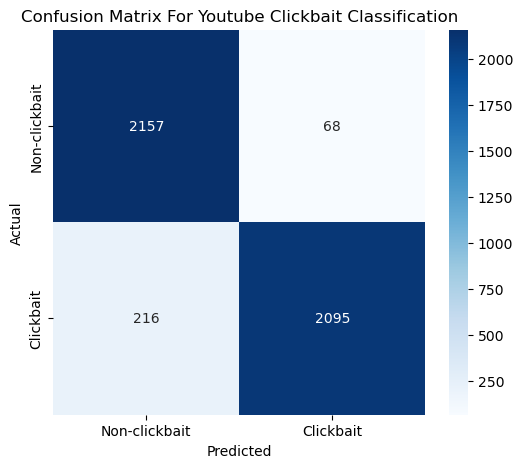

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=["Non-clickbait","Clickbait"],

    yticklabels=["Non-clickbait","Clickbait"]

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix For Youtube Clickbait Classification")

plt.show()


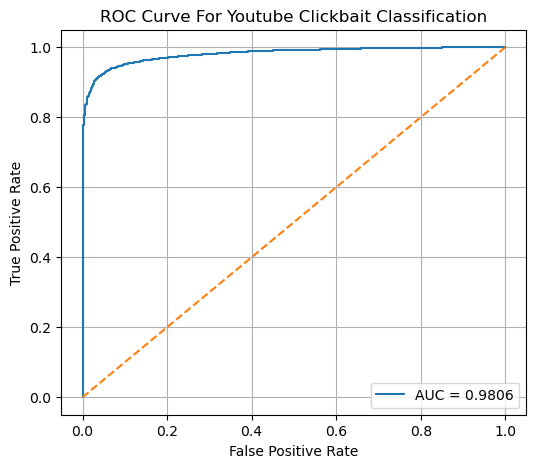

In [49]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(

    y_test,

    y_prob

)

roc_auc = auc(

    fpr,

    tpr

)

plt.figure(figsize=(6,5))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {roc_auc:.4f}"

)

plt.plot(

    [0,1],

    [0,1],

    linestyle="--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve For Youtube Clickbait Classification")

plt.legend()

plt.grid()


plt.show()


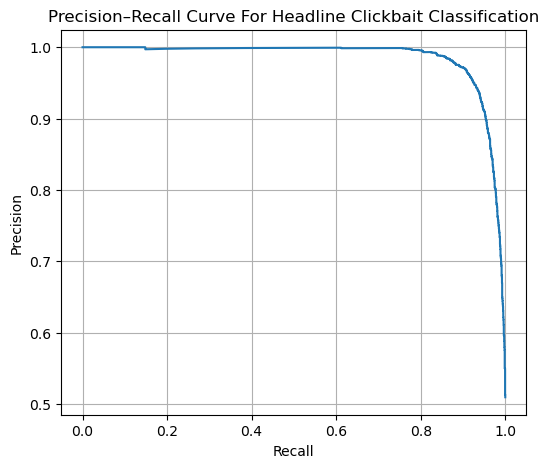

In [50]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, _ = precision_recall_curve(

    y_test,

    y_prob

)

plt.figure(figsize=(6,5))

plt.plot(

    recall_curve,

    precision_curve

)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision–Recall Curve For Headline Clickbait Classification")

plt.grid()


plt.show()




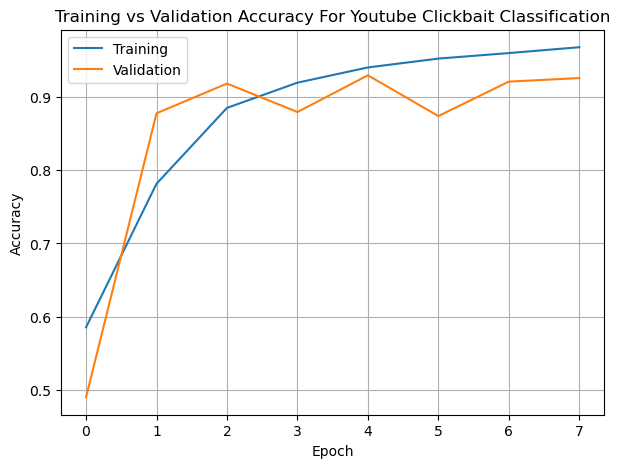

In [52]:
plt.figure(figsize=(7,5))

plt.plot(

    history.history["accuracy"],

    label="Training"

)

plt.plot(

    history.history["val_accuracy"],

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy For Youtube Clickbait Classification")

plt.legend()

plt.grid()

plt.show()



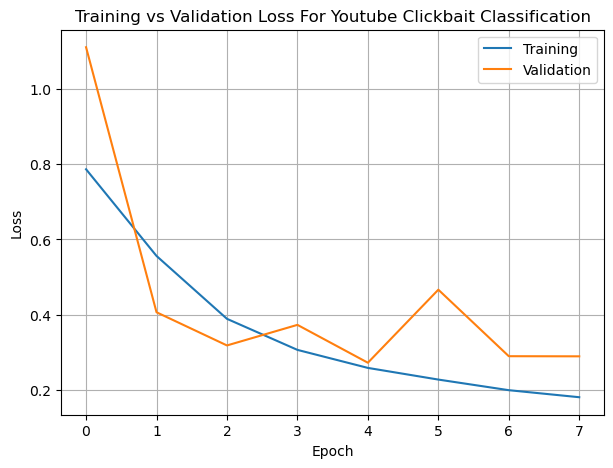

In [53]:
plt.figure(figsize=(7,5))

plt.plot(

    history.history["loss"],

    label="Training"

)

plt.plot(

    history.history["val_loss"],

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss For Youtube Clickbait Classification")

plt.legend()

plt.grid()
plt.show()



In [54]:
results = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1-score",

        "ROC-AUC"

    ],

    "Value":[

        accuracy,

        precision,

        recall,

        f1,

        roc_auc

    ]

})

display(results)


,Metric,Value
0,Accuracy,0.937390
1,Precision,0.968562
2,Recall,0.906534
3,F1-score,0.936522
4,ROC-AUC,0.980612
